In [1]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# Common imports
import numpy as np
import os

In [2]:
# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "classification"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

In [3]:
base_dir = './UAV_Classification_Dataset/dataset/MFCC'

# taking a subset of data to start

class_names = ['Autel_Evo_II', 'David_Tricopter']
os.listdir(base_dir)

['DJI_Phantom2',
 'UDI_U46',
 'Syma_X20',
 'Hasakee_Q11',
 'Hover_X1',
 'PhenoBee',
 'DJI_Matrice200_v2',
 'DJI_Mini3_pro',
 'Yuneec_Typhoon_H_Plus',
 'DJI_Phantom4',
 'DJI_Tello_TT',
 'DJI_FPV',
 'Syma_X26',
 'DJI_Tello',
 'DJI_Matrice600p',
 'DJI_Neo',
 'Holystone_HS210',
 'DJI_Avata',
 'DJI_Mavic2s',
 'DJI_Mavic_Air2',
 'Autel_Evo_II',
 'DJI_Mini3',
 'DJI_Mavic_Mini1',
 'DJI_Mavic_Mini2',
 'Syma_X8SW',
 'Syma_X5UW',
 'DJI_Mavic2pro',
 'DJI_Matrice200',
 'Syma_X20P',
 'David_Tricopter',
 'Swellpro_Splash3_plus',
 'Syma_X5SW']

In [4]:
# ------------------------------------
# PREP DATA
# ------------------------------------

In [5]:
base_name = 'cases_resized'
width = 80

In [5]:
# getting number of instances per class
for class_name in class_names:
    class_folder = os.path.join(base_dir, class_name);
    files = [f for f in os.listdir(class_folder)]
    print(class_name + ": " + str(len(files)) + " instances in class")

Autel_Evo_II: 100 instances in class
David_Tricopter: 100 instances in class


In [6]:
# RESIZE IMAGES
import joblib
from skimage.io import imread
from skimage.transform import resize

def resize_all(src, pklname, include, width=150, height=None):
    """
    load images from path, resize them and write them as arrays to a dictionary,
    together with labels and metadata. The dictionary is written to a pickle file
    named '{pklname}_{width}x{height}px.pkl'.

    Parameter
    ---------
    src: str
        path to data
    pklname: str
        path to output file
    width: int
        target width of the image in pixels
    include: set[str]
        set containing str
    """
    height = height if height is not None else width

    data = dict()
    data['description'] = 'resized ({0}x{1})MFCC extractions in rgb'.format(int(width), int(height))
    data['label'] = []
    data['filename'] = []
    data['data'] = []

    pklname = f"{pklname}_{width}x{height}px.pkl"

    # read all images in PATH, resize and write to DESTINATION_PATH
    for subdir in os.listdir(src):
        if subdir in include:
            print(subdir)
            current_path = os.path.join(src, subdir)

            for file in os.listdir(current_path):
                if file[-3:] in {'jpg', 'png'}:
                    im = imread(os.path.join(current_path, file))
                    im = resize(im, (width, height)) #[:,:,::-1]
                    data['label'].append(subdir[:-4])
                    data['filename'].append(file)
                    data['data'].append(im)

        joblib.dump(data, pklname)

In [6]:
# RESIZE IMAGES
!pip install imageio[pyav]

data_path = './UAV_Classification_Dataset/dataset/MFCC'
base_name = 'cases_resized'
width = 80
# ##### VERY SMALL VERSION ######
# include = {
#      'Autel_Evo_II', 'David_Tricopter'
#  }
# resize_all(src=data_path, pklname=base_name, width=width, include=include)

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [7]:
# load the data from disk and print a summary
import joblib
from collections import Counter
 
data = joblib.load(f'{base_name}_{width}x{width}px.pkl')
 
print('number of samples: ', len(data['data']))
print('keys: ', list(data.keys()))
print('description: ', data['description'])
print('image shape: ', data['data'][0].shape)
print('labels:', np.unique(data['label']))
 
Counter(data['label'])

number of samples:  200
keys:  ['description', 'label', 'filename', 'data']
description:  resized (80x80)animal images in rgb
image shape:  (80, 80, 4)
labels: ['Autel_Ev' 'David_Trico']


Counter({'Autel_Ev': 100, 'David_Trico': 100})

In [37]:
# name input data X and result (labels) y
X = np.array(data['data'])
y = np.array(data['label'])

In [9]:
# from sklearn.model_selection import train_test_split
 
# X_train, X_test, y_train, y_test = train_test_split(
#     X, 
#     y, 
#     test_size=0.2, 
#     shuffle=True,
#     random_state=42,
# )

In [10]:
# print(X_train.shape, y_train.shape)

(160, 80, 80, 4) (160,)


In [11]:
# ------------------------------
# HOG TRANSFORMATION
# ------------------------------

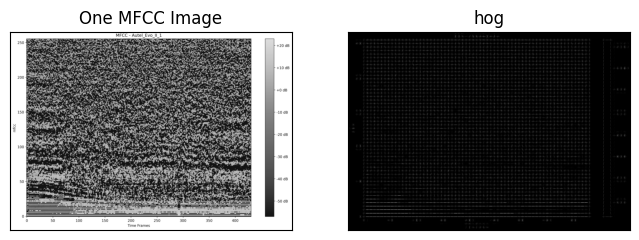

In [9]:
# For one image ++++++
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import rescale
 
one_mfcc = imread('./UAV_Classification_Dataset/dataset/MFCC/Autel_Evo_II/Autel_Evo_II_1_mfcc.png', as_gray=True)
# https://en.wikipedia.org/wiki/German_Shepherd#/media/File:Kim_at_14_weeks.jpg
 
# scale down the image to one third
one_mfcc = rescale(one_mfcc, 1/3, mode='reflect')
# calculate the hog and return a visual representation.
one_mfcc_hog, one_mfcc_hog_img = hog(
    one_mfcc, pixels_per_cell=(14,14), 
    cells_per_block=(2, 2), 
    orientations=9, 
    visualize=True, 
    block_norm='L2-Hys')
 
fig, ax = plt.subplots(1,2)
fig.set_size_inches(8,6)
# remove ticks and their labels
[a.tick_params(bottom=False, left=False, labelbottom=False, labelleft=False) 
    for a in ax]
 
ax[0].imshow(one_mfcc, cmap='gray')
ax[0].set_title('One MFCC Image')
ax[1].imshow(one_mfcc_hog_img, cmap='gray')
ax[1].set_title('hog')
plt.show()

In [10]:
# reduced pixels to be analyzed to ~15% and can still recognise img

print('number of pixels: ', one_mfcc.shape[0] * one_mfcc.shape[1])
print('number of hog features: ', one_mfcc_hog.shape[0])

number of pixels:  882560
number of hog features:  156420


In [11]:
from skimage.feature import hog
from skimage.io import imread
from skimage.transform import rescale

from sklearn.base import BaseEstimator, TransformerMixin

class RGB2GrayTransformer(BaseEstimator, TransformerMixin):
    # Convert an array of RGB images to grayscale
 
    def __init__(self):
        pass
 
    def fit(self, X, y=None):
        """returns itself"""
        return self
 
    def transform(self, X, y=None):
        """perform the transformation and return an array"""
        """ slice img as [:, :, :3] to only keep RGB channel and discard Alpha channel to avoid errors """
        return np.array([skimage.color.rgb2gray(img[:, :, :3]) for img in X])

class HogTransformer(BaseEstimator, TransformerMixin):
    # Expects an array of 2d arrays (1 channel images)
    # Calculates hog features for each img
 
    def __init__(self, y=None, orientations=9,
                 pixels_per_cell=(8, 8),
                 cells_per_block=(3, 3), block_norm='L2-Hys'):
        self.y = y
        self.orientations = orientations
        self.pixels_per_cell = pixels_per_cell
        self.cells_per_block = cells_per_block
        self.block_norm = block_norm
        # self.visualize=True
        # self.feature_vector=False
            
    def fit(self, X, y=None):
        return self
 
    def transform(self, X, y=None):
 
        def local_hog(X):
            return hog(X,
                       orientations=self.orientations,
                       pixels_per_cell=self.pixels_per_cell,
                       cells_per_block=self.cells_per_block,
                       block_norm=self.block_norm)
 
        try: # parallel
            return np.array([local_hog(img) for img in X])
        except:
            return np.array([local_hog(img) for img in X])

In [12]:
# preprocess RGB images to scaled HOG features

from sklearn.linear_model import SGDClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler, Normalizer
import skimage

# SLICE ARRAY TO ONLY KEEP FIRST 3 CHANNELS, AVOID 4 DIMENSIONS ISSUE

# create an instance of each transformer
grayify = RGB2GrayTransformer()
hogify = HogTransformer(
    pixels_per_cell=(14, 14), 
    cells_per_block=(2,2), 
    orientations=9, 
    block_norm='L2-Hys',
    # visualize=True,
    # feature_vector=False
)
# The feature_vector=False parameter is crucial here. It tells hog to return the HOG features in their spatial (multidimensional) 
# structure rather than as a flattened 1D feature vector

scalify = StandardScaler()

# TRY TO MAKE X DIMENSIONS WORK
# X = imageio.imread(X)[:,:,:3]

# call fit_transform on each transform converting X step by step
X_gray = grayify.fit_transform(X)
X_hog = hogify.fit_transform(X_gray)
X_prepared = scalify.fit_transform(X_hog)
 
print(X_prepared.shape)
# currently returning the hog images, not features

(200, 576)


In [57]:
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X_prepared, 
    y, 
    test_size=0.2, 
    shuffle=True,
    random_state=42,
)

In [58]:
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(160, 576) (160,) (40, 576) (40,)


In [15]:
# ------------------------------------------------
# DEVELOP SIMPLE CNN NETWORK (PRACTICE)
# https://www.tensorflow.org/tutorials/images/cnn
# ------------------------------------------------

In [18]:
import tensorflow as tf

from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt

In [59]:
# Normalize pixel values to be between 0 and 1

X_train, X_test = X_train / 255.0, X_test / 255.0

In [31]:
# print(X_train.shape, X_test.shape)

(160, 576) (40, 576)


In [62]:
# Create convolutional base
import keras
from keras import layers

model = keras.Sequential()
# input flat array of HOG features
model.add(keras.Input(shape=(576,)))
# resphapeto 24x24 image with 1 color channel, greyscale
model. add(layers.Reshape((24, 24, 1)))

model.add(layers.Conv2D(32, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [63]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 2, 2, 64)       │        36,928 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,744 (217.75 KB)

 Trainable params: 55,744 (217.75 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
# add dense layers on top

model.add(layers.Flatten())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dense(10))

In [65]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 24, 24, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 22, 22, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 11, 11, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 9, 9, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 2, 2, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,842 (284.54 KB)

 Trainable params: 72,842 (284.54 KB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# prep testing train/test data
from sklearn.model_selection import train_test_split
 
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.2, 
    shuffle=True,
    random_state=42,
)

In [39]:
X_train, X_test = X_train / 255.0, X_test / 255.0


In [66]:
# compile and train model
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

# This turns words like ['cat', 'dog', 'cat'] into [0, 1, 0]
y_train = encoder.fit_transform(y_train)
y_test = encoder.transform(y_test)

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10, 
                    validation_data=(X_test, y_test))

Epoch 1/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 499ms/step - accuracy: 0.2922 - loss: 2.2841 - val_accuracy: 0.5250 - val_loss: 2.1814
Epoch 2/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.4823 - loss: 2.1045 - val_accuracy: 0.5250 - val_loss: 1.7239
Epoch 3/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.5227 - loss: 1.5358 - val_accuracy: 0.5250 - val_loss: 0.9266
Epoch 4/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4940 - loss: 0.8705 - val_accuracy: 0.5250 - val_loss: 0.7008
Epoch 5/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5106 - loss: 0.7029 - val_accuracy: 0.4750 - val_loss: 0.7304
Epoch 6/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.5412 - loss: 0.6927 - val_accuracy: 0.5250 - val_loss: 0.7164
Epoch 7/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.4571 - loss: 0.7433 - val_accuracy: 0.4750 - val_loss: 0.7010
Epoch 8/10
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.5225 - loss: 0.6993 - val_accuracy: 0.5250 - val_loss: 0.6932

2/2 - 0s - 26ms/step - accuracy: 0.4750 - loss: 0.7189


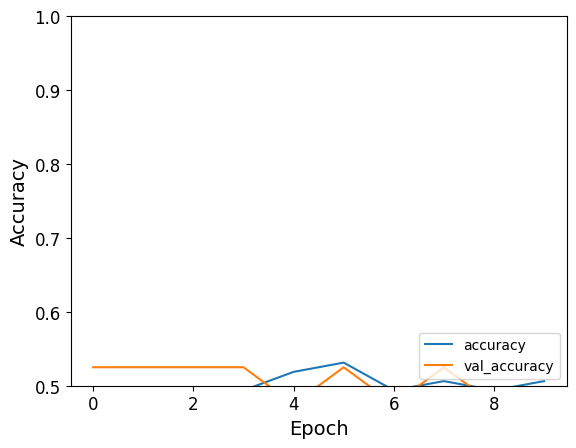

In [67]:
plt.plot(history.history['accuracy'], label='accuracy')
plt.plot(history.history['val_accuracy'], label = 'val_accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')

test_loss, test_acc = model.evaluate(X_test,  y_test, verbose=2)

In [68]:
print(test_acc)

0.4749999940395355


In [ ]:
# HOG = WORSE ACCURACY **************************************************************

In [18]:
# --------------------------------
# TRAIN SGD CLASSIFIER (PRACTICE)
# --------------------------------

In [25]:
# Stochastic Gradient Descent Tester

In [47]:
# create instance and call fit method passing data and training labels

sgd_clf = SGDClassifier(random_state=42, max_iter=1000, tol=1e-3)
sgd_clf.fit(X_train_prepared, y_train)

SGDClassifier(random_state=42)

In [48]:
# To test the trained SGD classifier, we will use our test set. First, we transform it using the same transformers as before. 
# However, we must take care that our test data will not influence the transformers. Some transformers, like PCA (Principle 
# Component Analysis), can optimise themselves on the data before applying the transformation. To prevent this, we call transform 
# and not fit_transform on the test data

X_test_gray = grayify.transform(X_test)
X_test_hog = hogify.transform(X_test_gray)
X_test_prepared = scalify.transform(X_test_hog)

In [49]:
# make a prediction for our test set and look at the results. How many of the predictions match with y_test?

y_pred = sgd_clf.predict(X_test_prepared)
print(np.array(y_pred == y_test)[:25])
print('')
print('Percentage correct: ', 100*np.sum(y_pred == y_test)/len(y_test))

[ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
 False]

Percentage correct:  95.0


In [50]:
sgd_clf.score(X_test_prepared, y_test)

0.95

In [51]:
# confusion matrix to get more insight into results (each row is label, each column is prediction)

# illustration 

import pandas as pd

labels = ['yes', 'yes', 'yes', 'yes', 'yes', 'yes', 'no',  'no', 'no', 'no']
predictions = ['yes', 'yes', 'yes', 'yes', 'no',  'no',  'yes', 'no', 'no', 'no']
 
# put the data in a dataframe for pretty printing
df = pd.DataFrame(
    np.c_[labels, predictions], 
    columns=['true_label', 'prediction']
)
df

,true_label,prediction
0,yes,yes
1,yes,yes
2,yes,yes
3,yes,yes
4,yes,no
5,yes,no
6,no,yes
7,no,no
8,no,no
9,no,no


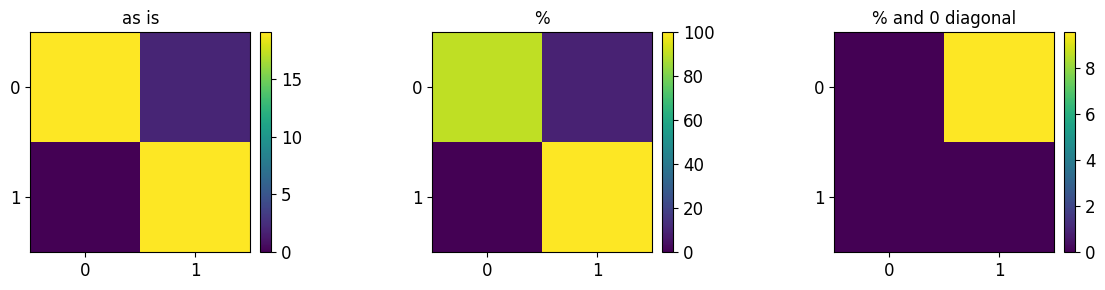


 [np.str_('Autel_Ev'), np.str_('David_Trico')]


In [54]:
# confusion matrix
cmx = confusion_matrix(y_test, y_pred)
cmx

from mpl_toolkits.axes_grid1 import make_axes_locatable
 
def plot_confusion_matrix(cmx, vmax1=None, vmax2=None, vmax3=None):
    cmx_norm = 100*cmx / cmx.sum(axis=1, keepdims=True)
    cmx_zero_diag = cmx_norm.copy()
 
    np.fill_diagonal(cmx_zero_diag, 0)
 
    fig, ax = plt.subplots(ncols=3)
    fig.set_size_inches(12, 3)
    [a.set_xticks(range(len(cmx)+1)) for a in ax]
    [a.set_yticks(range(len(cmx)+1)) for a in ax]
         
    im1 = ax[0].imshow(cmx, vmax=vmax1)
    ax[0].set_title('as is')
    im2 = ax[1].imshow(cmx_norm, vmax=vmax2)
    ax[1].set_title('%')
    im3 = ax[2].imshow(cmx_zero_diag, vmax=vmax3)
    ax[2].set_title('% and 0 diagonal')
 
    dividers = [make_axes_locatable(a) for a in ax]
    cax1, cax2, cax3 = [divider.append_axes("right", size="5%", pad=0.1) 
                        for divider in dividers]
 
    fig.colorbar(im1, cax=cax1)
    fig.colorbar(im2, cax=cax2)
    fig.colorbar(im3, cax=cax3)
    fig.tight_layout()
    plt.show()
     
plot_confusion_matrix(cmx)

# the types appear in this order
print('\n', sorted(np.unique(y_test)))

In [19]:
#-------------------------------------------------------------------------------------
#----------------------------- PIPELINE ----------------------------------------------
#-------------------------------------------------------------------------------------

from sklearn.pipeline import Pipeline
from sklearn import svm
 
HOG_pipeline = Pipeline([
    ('grayify', RGB2GrayTransformer()),
    ('hogify', HogTransformer(
        pixels_per_cell=(14, 14), 
        cells_per_block=(2, 2), 
        orientations=9, 
        block_norm='L2-Hys')
    ),
    ('scalify', StandardScaler()),
    ('classify', SGDClassifier(random_state=42, max_iter=1000, tol=1e-3))
])
 
clf = HOG_pipeline.fit(X_train, y_train)
print('Percentage correct: ', 100*np.sum(clf.predict(X_test) == y_test)/len(y_test))

Percentage correct:  95.0


In [57]:
########################################
# EXPERIMENT WITH CNN Transfer Learning
########################################

In [21]:
# !pip install opencv-python
!pip install tensorflow[and-cuda]

import numpy as np
from keras import utils
from keras.models import Model, Sequential, load_model
from keras.layers import Dense, Conv2D, MaxPooling2D, Flatten, Reshape, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50
from sklearn.metrics import confusion_matrix, classification_report
import itertools
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python3 -m pip install --upgrade pip


In [63]:
# Get VGG-16 Model
def getVGG16Model(lastFourTrainable=False):
  vgg_model = VGG16(weights='imagenet', input_shape=input_shape, include_top=True)

  # Make all layers untrainable
  for layer in vgg_model.layers[:]:
      layer.trainable = False

  # Add fully connected layer which have 1024 neuron to VGG-16 model
  output = vgg_model.get_layer('fc2').output
  output = Flatten(name='new_flatten')(output)
  output = Dense(units=1024, activation='relu', name='new_fc')(output)
  output = Dense(units=10, activation='softmax')(output)
  vgg_model = Model(vgg_model.input, output)

  # Make last 4 layers trainable if lastFourTrainable == True
  if lastFourTrainable == True:
    vgg_model.get_layer('block5_conv3').trainable = True
    vgg_model.get_layer('fc1').trainable = True
    vgg_model.get_layer('fc2').trainable = True
    vgg_model.get_layer('new_fc').trainable = True

  # Compile VGG-16 model
  vgg_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  vgg_model.summary()

  return vgg_model
  

# Get ResNet-50 Model
def getResNet50Model(lastFourTrainable=False):
  resnet_model = ResNet50(weights='imagenet', input_shape=input_shape, include_top=True)

  # Make all layers non-trainable
  for layer in resnet_model.layers[:]:
      layer.trainable = False

  # Add fully connected layer which have 1024 neuron to ResNet-50 model
  output = resnet_model.get_layer('avg_pool').output
  output = Flatten(name='new_flatten')(output)
  output = Dense(units=1024, activation='relu', name='new_fc')(output)
  output = Dense(units=10, activation='softmax')(output)
  resnet_model = Model(resnet_model.input, output)

  # Make last 4 layers trainable if lastFourTrainable == True
  if lastFourTrainable == True:
    resnet_model.get_layer('conv5_block3_2_bn').trainable = True
    resnet_model.get_layer('conv5_block3_3_conv').trainable = True
    resnet_model.get_layer('conv5_block3_3_bn').trainable = True
    resnet_model.get_layer('new_fc').trainable = True

  # Compile ResNet-50 model
  resnet_model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
  resnet_model.summary()
  
  return resnet_model

In [65]:
getVGG16Model()

NameError: name 'input_shape' is not defined